# Dead-End Detection Evaluation: Discrete vs Continuous Action Spaces

This notebook evaluates how well the Q_D (dead-end) and Q_R (rescue) networks identify the true dead-end region in SpaceEnv, comparing discrete and continuous action space agents.

**Core claim**: Discrete agents evaluate Q_D only at n_bins² fixed grid points. Near the critical radius r_c, the angular escape window may fall between grid points, causing misclassification. Continuous agents use random shooting over arbitrary actions and can find the true escape direction.

**Ground truth**: State (x, y, vx, vy) is a dead end iff `dist((x,y), (5,5)) < r_c = 2.0`.

**References**:
- Fatemi et al. (2021) *Dead-End Discovery for Safe RL* — DeD framework, precision/recall of dead-end labelling
- Bellemare et al. (2017) *A Distributional Perspective on RL* — distributional Q values
- Garcia & Fernandez (2015) *A Comprehensive Survey on Safe RL* — constraint violation metrics

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/ContinuousDeD-master/toy_domain/

/content/drive/MyDrive/ContinuousDeD-master/toy_domain


In [30]:
!python run.py -agent iqn -action_mode discrete -n_bins 5 -ded -info ded_discrete_5bins -frames 50000 -eval_every 2000 -eps_frames 5000

2026-03-11 16:38:38.475360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773247118.495621    5854 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773247118.502396    5854 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773247118.519597    5854 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773247118.519621    5854 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773247118.519626    5854 computation_placer.cc:177] computation placer alr

In [31]:
!python run.py -agent iqn -action_mode continuous -K_actions 64 -ded -info ded_continuous_K64 -frames 50000 -eval_every 2000 -eps_frames 5000

2026-03-11 16:53:12.941862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773247992.962876    9561 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773247992.969873    9561 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773247992.999952    9561 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773247992.999977    9561 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773247992.999983    9561 computation_placer.cc:177] computation placer alr

## 0. Setup

In [8]:
import sys, os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# --- Path setup ---
REPO_ROOT = os.path.abspath('.')   # assumes notebook is run from SafetyResearch/
sys.path.insert(0, os.path.join(REPO_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'SpaceEnv'))

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print('Device:', device)

Device: cpu


## 1. Configuration

Set the paths to your trained agent pickle files and evaluation parameters here.

In [17]:
# ── Agent pickle paths ──────────────────────────────────────────────────────
# Adjust these to match your run names.
RUN_DIR = os.path.join(REPO_ROOT, 'runs')

DISCRETE_RUN   = 'ded_discrete_5bins'   # name passed to -info when training
CONTINUOUS_RUN = 'continuous_iqn'

discrete_Qd_path   = os.path.join(RUN_DIR, DISCRETE_RUN,   DISCRETE_RUN   + '_Qd.pkl')
discrete_Qr_path   = os.path.join(RUN_DIR, DISCRETE_RUN,   DISCRETE_RUN   + '_Qr.pkl')
continuous_Qd_path = os.path.join(RUN_DIR, CONTINUOUS_RUN, CONTINUOUS_RUN + '_Qd.pkl')
continuous_Qr_path = os.path.join(RUN_DIR, CONTINUOUS_RUN, CONTINUOUS_RUN + '_Qr.pkl')

# ── Environment constants ────────────────────────────────────────────────────
PLANET_CENTER = np.array([5.0, 5.0])
PLANET_RADIUS = 1.0      # physical planet body (agent crashes if inside)
R_C           = 2.0      # critical radius — ground truth dead-end boundary
MAP_SIZE      = 10.0
A_MAX         = 0.5      # max thrust per axis

# ── Evaluation parameters ───────────────────────────────────────────────────
N_BINS_DISCRETE  = 5     # must match the n_bins used during training
K_EVAL           = 512   # action samples for continuous scoring
N_TAU_EVAL       = 32    # quantile samples when calling IQN forward
GRID_RES         = 60    # grid resolution for spatial plots (60×60 = 3600 test states)
DELTA_BOUNDARY   = 0.5   # half-width of annular boundary zone around r_c

# Threshold sweep for ROC/PR curves — Q_D ∈ [-1, 0]
THRESHOLDS = np.linspace(-1.0, 0.0, 300)

print('Discrete  Qd:', discrete_Qd_path)
print('Continuous Qd:', continuous_Qd_path)


Discrete  Qd: /home/jay/Uni/SafetyResearch/toy_domain/runs/ded_discrete_5bins/ded_discrete_5bins_Qd.pkl
Continuous Qd: /home/jay/Uni/SafetyResearch/toy_domain/runs/continuous_iqn/continuous_iqn_Qd.pkl


## 2. Load Agents

In [18]:
import io
from ReplayBuffers import ReplayBuffer

class CpuUnpickler(pickle.Unpickler):
    """Unpickler that redirects CUDA tensors to CPU and resolves renamed classes."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu', weights_only=False)
        return super().find_class(module, name)

def load_agent(path):
    with open(path, 'rb') as f:
        agent = CpuUnpickler(f).load()
    agent.qnetwork_local.to(device)
    agent.qnetwork_local.eval()
    return agent

disc_Qd = load_agent(discrete_Qd_path)
disc_Qr = load_agent(discrete_Qr_path)
cont_Qd = load_agent(continuous_Qd_path)
cont_Qr = load_agent(continuous_Qr_path)

# Infer action grid from discrete agent's action_size
n_bins = int(round(disc_Qd.action_size ** 0.5))
bins   = np.linspace(-A_MAX, A_MAX, n_bins, dtype=np.float32)
ACTION_MAP = np.array([(ax, ay) for ax in bins for ay in bins], dtype=np.float32)
print(f'Discrete action grid: {n_bins}×{n_bins} = {len(ACTION_MAP)} actions')
print(f'Continuous action dim: {cont_Qd.action_dim}, K_actions: {cont_Qd.K_actions}')

Discrete action grid: 5×5 = 25 actions
Continuous action dim: 2, K_actions: 32


## 3. Test State Generation

We generate a uniform (x, y) grid with vx=vy=0 and label each point using the analytic ground truth. We also create a denser stratified sample near r_c for boundary-zone analysis.

In [19]:
def make_grid_states(res=GRID_RES, margin=0.25):
    """Uniform (x,y) grid with vx=vy=0, excluding interior of planet body."""
    xs = np.linspace(margin, MAP_SIZE - margin, res)
    ys = np.linspace(margin, MAP_SIZE - margin, res)
    xx, yy = np.meshgrid(xs, ys)
    xy = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (res², 2)
    vxvy = np.zeros((len(xy), 2), dtype=np.float32)
    states = np.concatenate([xy, vxvy], axis=1).astype(np.float32)  # (N, 4)

    # Ground-truth labels
    dist = np.linalg.norm(xy - PLANET_CENTER, axis=1)
    inside_planet = dist < PLANET_RADIUS
    gt_dead_end   = dist < R_C

    # Mask out planet interior (agent can't be there)
    mask = ~inside_planet
    return states[mask], gt_dead_end[mask], dist[mask], xx, yy

states, gt_labels, dist_to_planet, xx, yy = make_grid_states()

# Zone labels
zone_inner    = dist_to_planet < (R_C - DELTA_BOUNDARY)
zone_boundary = (dist_to_planet >= R_C - DELTA_BOUNDARY) & (dist_to_planet <= R_C + DELTA_BOUNDARY)
zone_outer    = dist_to_planet > (R_C + DELTA_BOUNDARY)

states_t = torch.FloatTensor(states).to(device)

print(f'Test states: {len(states)}')
print(f'  True dead ends:  {gt_labels.sum()} ({100*gt_labels.mean():.1f}%)')
print(f'  True rescuable:  {(~gt_labels).sum()}')
print(f'  Boundary zone (|d - r_c| < {DELTA_BOUNDARY}): {zone_boundary.sum()}')

Test states: 3480
  True dead ends:  364 (10.5%)
  True rescuable:  3116
  Boundary zone (|d - r_c| < 0.5): 480


## 7.5. Figure 2.5 -- Actions to avoid

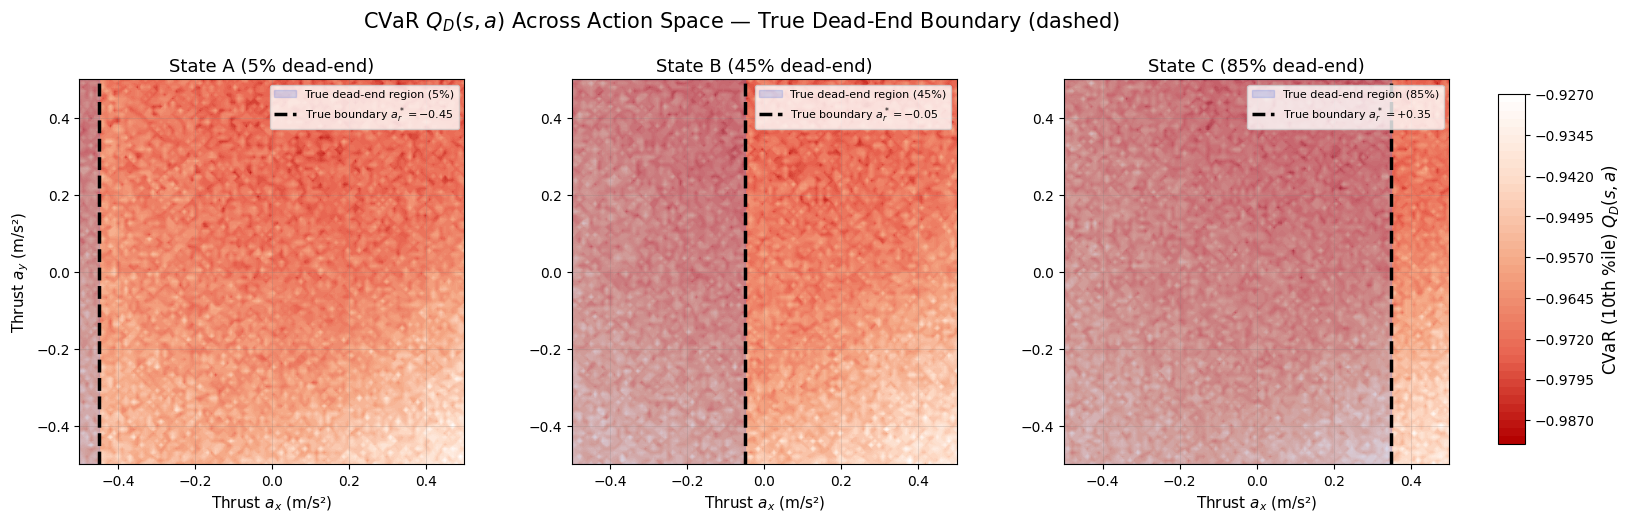

In [20]:
from model_continuous import _DRM
from matplotlib.colors import LinearSegmentedColormap

# Fix device attribute on continuous models (loaded from CUDA checkpoints)
for _agent in [cont_Qd, cont_Qr]:
    _agent.qnetwork_local.device = str(device)
    _agent.qnetwork_local.pis = _agent.qnetwork_local.pis.to(device)

# Red-to-white colormap: low CVaR scores → red (risky), high → white (safe)
cmap_risk = LinearSegmentedColormap.from_list('risk', ['#b30000', '#e86450', '#f4a582', '#fddbc7', '#ffffff'])

# Anchor states and true critical actions a_r* derived analytically
# Dead-end region: a_x ∈ [-0.5, a_r*] for all a_y  (vertical strip)
# Dead-end fraction = (a_r* + 0.5) / 1.0
ANCHOR_STATES = [
    [8.0, 5.0, -0.484, 0.0],  # State A: 5%  dead-end fraction, a_r* = -0.45
    [8.0, 5.0, -0.526, 0.0],  # State B: 45% dead-end fraction, a_r* = -0.05
    [8.0, 5.0, -0.566, 0.0],  # State C: 85% dead-end fraction, a_r* = +0.35
]
TRUE_BOUNDARIES = [-0.45, -0.05, 0.35]  # critical a_x for each state
DEAD_END_FRACS  = [0.05,  0.45,  0.85]
anchor_names = ["State A (5% dead-end)", "State B (45% dead-end)", "State C (85% dead-end)"]

# Continuous action meshgrid
A_RES = 100
ax_vals = np.linspace(-A_MAX, A_MAX, A_RES)
ay_vals = np.linspace(-A_MAX, A_MAX, A_RES)
AA_X, AA_Y = np.meshgrid(ax_vals, ay_vals)
actions_flat   = np.stack([AA_X.ravel(), AA_Y.ravel()], axis=1)
actions_tensor = torch.FloatTensor(actions_flat).to(device)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (state_vals, name, a_star, de_frac) in enumerate(
        zip(ANCHOR_STATES, anchor_names, TRUE_BOUNDARIES, DEAD_END_FRACS)):
    ax = axes[i]

    # Expand state over all actions
    states_tensor = (torch.FloatTensor(state_vals)
                     .unsqueeze(0).expand(len(actions_flat), -1).to(device))

    with torch.no_grad():
        # CVaR (10th percentile) of Q_D
        original_drm = cont_Qd.qnetwork_local.drm
        cont_Qd.qnetwork_local.drm = _DRM(name='cvar', eta=0.1)
        q_cvar = cont_Qd.qnetwork_local.get_qvalue(states_tensor, actions_tensor, use_drm=True)
        q_cvar = q_cvar.cpu().numpy().reshape(A_RES, A_RES)
        cont_Qd.qnetwork_local.drm = original_drm

    # ── CVaR heatmap ──────────────────────────────────────────────────────
    im = ax.contourf(AA_X, AA_Y, q_cvar, levels=50, cmap=cmap_risk,
                     vmin=q_cvar.min(), vmax=q_cvar.max())

    # ── True dead-end region shading (a_x ≤ a_r*) ─────────────────────────
    ax.axvspan(-A_MAX, a_star, alpha=0.20, color='royalblue',
               label=f'True dead-end region ({de_frac:.0%})')

    # ── True boundary: vertical line at a_r* ──────────────────────────────
    ax.axvline(a_star, color='black', linewidth=2.5, linestyle='--',
               label=f'True boundary $a_r^*={a_star:+.2f}$')

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Thrust $a_x$ (m/s²)", fontsize=11)
    if i == 0:
        ax.set_ylabel("Thrust $a_y$ (m/s²)", fontsize=11)
    ax.set_xlim(-A_MAX, A_MAX)
    ax.set_ylim(-A_MAX, A_MAX)
    ax.set_aspect('equal')
    ax.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

# Unified colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("CVaR (10th %ile) $Q_D(s, a)$", fontsize=12)

fig.suptitle(
    r"CVaR $Q_D(s,a)$ Across Action Space — True Dead-End Boundary (dashed)",
    fontsize=15, y=1.02)
plt.subplots_adjust(right=0.9)
# plt.savefig('fig2_5a_cvar_actions.pdf', bbox_inches='tight')
plt.show()


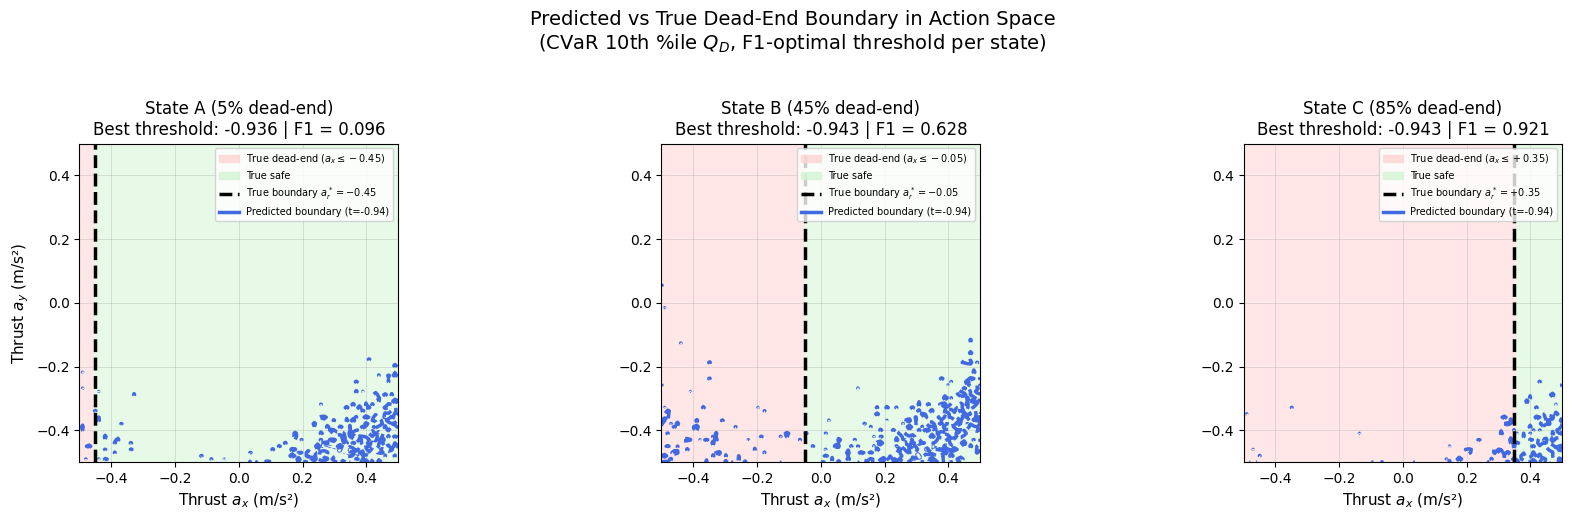

In [21]:
## Figure 2.5b — Predicted Dead-End Boundary in Action Space
#
# For each anchor state we:
#   1. Score every action with CVaR Q_D(s, a)  (10th percentile, same as Fig 2.5a).
#   2. Sweep thresholds and find the one that maximises F1 against the analytic
#      ground-truth labels (dead-end iff a_x <= a_r*).
#   3. Plot the predicted boundary (CVaR Q_D = threshold contour) against the true boundary.

def score_actions_cvar(agent, state_vals, actions_tensor, eta=0.1):
    """CVaR Q_D(s, a) at risk level eta for every action in actions_tensor. Returns (N,)."""
    net = agent.qnetwork_local
    states_tensor = (torch.FloatTensor(state_vals)
                     .unsqueeze(0).expand(len(actions_tensor), -1).to(device))
    original_drm = net.drm
    net.drm = _DRM(name='cvar', eta=eta)
    with torch.no_grad():
        q = net.get_qvalue(states_tensor, actions_tensor, use_drm=True)  # (N, 1)
    net.drm = original_drm
    return q.cpu().numpy().flatten()


def best_action_threshold(q_vals, true_dead, thresholds=np.linspace(-1.0, 0.0, 300)):
    """F1-optimal threshold for classifying actions as dead-end (q < t)."""
    best_f1, best_t = -1.0, thresholds[0]
    for t in thresholds:
        pred = q_vals < t
        TP = ( pred &  true_dead).sum()
        FP = ( pred & ~true_dead).sum()
        FN = (~pred &  true_dead).sum()
        prec = TP / (TP + FP + 1e-9)
        rec  = TP / (TP + FN + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


# True action labels: dead-end iff a_x <= a_r*  (independent of a_y)
true_dead_flat = {a_star: (actions_flat[:, 0] <= a_star) for a_star in TRUE_BOUNDARIES}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (state_vals, name, a_star, de_frac) in enumerate(
        zip(ANCHOR_STATES, anchor_names, TRUE_BOUNDARIES, DEAD_END_FRACS)):
    ax = axes[i]

    # CVaR Q_D scores over action grid
    q_cvar = score_actions_cvar(cont_Qd, state_vals, actions_tensor, eta=0.1)
    q_grid = q_cvar.reshape(A_RES, A_RES)

    # Find F1-optimal threshold for this state
    td = true_dead_flat[a_star]
    opt_t, opt_f1 = best_action_threshold(q_cvar, td)

    # Background: true dead-end vs safe region
    true_de_grid = (AA_X <= a_star).astype(float)
    ax.contourf(AA_X, AA_Y, true_de_grid,
                levels=[-0.5, 0.5, 1.5],
                colors=['#d4f5d4', '#ffd5d5'],   # green=safe, red=dead-end
                alpha=0.55)

    # Predicted boundary: CVaR Q_D contour at optimal threshold
    try:
        cs = ax.contour(AA_X, AA_Y, q_grid, levels=[opt_t],
                        colors=['royalblue'], linewidths=2.5)
        ax.clabel(cs, fmt=f't={opt_t:.2f}', fontsize=8)
    except Exception:
        pass  # contour may fail if network output is too flat

    # True boundary: vertical dashed line at a_r*
    ax.axvline(a_star, color='black', linewidth=2.5, linestyle='--')

    ax.set_title(f"{name}\nBest threshold: {opt_t:.3f} | F1 = {opt_f1:.3f}", fontsize=12)
    ax.set_xlabel("Thrust $a_x$ (m/s²)", fontsize=11)
    if i == 0:
        ax.set_ylabel("Thrust $a_y$ (m/s²)", fontsize=11)
    ax.set_xlim(-A_MAX, A_MAX)
    ax.set_ylim(-A_MAX, A_MAX)
    ax.set_aspect('equal')
    ax.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    legend_elements = [
        mpatches.Patch(color='#ffd5d5', alpha=0.8, label=f'True dead-end ($a_x \\leq {a_star:+.2f}$)'),
        mpatches.Patch(color='#d4f5d4', alpha=0.8, label='True safe'),
        Line2D([0], [0], color='black', lw=2.5, ls='--', label=f'True boundary $a_r^*={a_star:+.2f}$'),
        Line2D([0], [0], color='royalblue', lw=2.5, ls='-',
               label=f'Predicted boundary (t={opt_t:.2f})'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='upper right')

fig.suptitle(
    r"Predicted vs True Dead-End Boundary in Action Space"
    "\n(CVaR 10th %ile $Q_D$, F1-optimal threshold per state)",
    fontsize=14, y=1.03)
plt.tight_layout()
# plt.savefig('fig2_5b_action_boundary.pdf', bbox_inches='tight')
plt.show()


## 4. Scoring Functions

**Dead-end score** = max_a Q_D(s, a) over the available action set.  
Higher (less negative) → agent thinks state is *not* a dead end.  
Classify as dead end when score < threshold (threshold ∈ [-1, 0]).

In [7]:
def score_discrete(agent, states_t, batch_size=256):
    """max over all discrete actions of mean-quantile Q_D(s,a). Shape: (N,)"""
    scores = []
    net = agent.qnetwork_local
    with torch.no_grad():
        for i in range(0, len(states_t), batch_size):
            s = states_t[i:i+batch_size]
            # IQN: get_qvalues returns (batch, action_size); DQN: forward returns same shape
            if hasattr(net, 'get_qvalues'):
                q = net.get_qvalues(s)          # (batch, n_actions)
            else:
                q = net.forward(s)
            scores.append(q.max(dim=1).values.cpu().numpy())
    return np.concatenate(scores)


def score_continuous(agent, states_t, K=K_EVAL, batch_size=128):
    """max over K random actions of Q_D(s,a). Shape: (N,)"""
    scores = []
    net = agent.qnetwork_local
    low  = torch.FloatTensor(agent.action_low).to(device)
    high = torch.FloatTensor(agent.action_high).to(device)
    a_dim = agent.action_dim
    with torch.no_grad():
        for i in range(0, len(states_t), batch_size):
            s = states_t[i:i+batch_size]          # (B, state_dim)
            B = s.shape[0]
            # Expand each state over K candidate actions
            s_exp = s.unsqueeze(1).expand(B, K, -1).reshape(B * K, -1)
            rand_u  = torch.rand(B * K, a_dim, device=device)
            actions = rand_u * (high - low) + low  # (B*K, a_dim)
            q = net.get_qvalue(s_exp, actions)      # (B*K, 1)
            q = q.view(B, K).max(dim=1).values      # (B,)
            scores.append(q.cpu().numpy())
    return np.concatenate(scores)


print('Scoring discrete Qd...')
disc_Qd_scores = score_discrete(disc_Qd, states_t)
print('Scoring discrete Qr...')
disc_Qr_scores = score_discrete(disc_Qr, states_t)
print('Scoring continuous Qd...')
cont_Qd_scores = score_continuous(cont_Qd, states_t, batch_size=8)  # smaller batch for continuous due to K action samples
print('Scoring continuous Qr...')
cont_Qr_scores = score_continuous(cont_Qr, states_t, batch_size=8)
print('Done.')

Scoring discrete Qd...
Scoring discrete Qr...
Scoring continuous Qd...
Scoring continuous Qr...
Done.


## 5. Metric Helpers

In [8]:
def classification_at_threshold(scores, gt, threshold):
    """Classify states as dead ends (score < threshold) and compute metrics."""
    pred = scores < threshold
    TP = (pred & gt).sum()
    FP = (pred & ~gt).sum()
    FN = (~pred & gt).sum()
    TN = (~pred & ~gt).sum()
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy  = (TP + TN) / len(gt)
    fpr       = FP / (FP + TN + 1e-9)
    return dict(TP=TP, FP=FP, FN=FN, TN=TN,
                precision=precision, recall=recall,
                f1=f1, accuracy=accuracy, fpr=fpr)


def sweep_thresholds(scores, gt, thresholds=THRESHOLDS):
    """Sweep thresholds and return arrays of metrics."""
    out = {k: [] for k in ['precision', 'recall', 'f1', 'accuracy', 'fpr', 'tpr']}
    for t in thresholds:
        m = classification_at_threshold(scores, gt, t)
        out['precision'].append(m['precision'])
        out['recall'].append(m['recall'])
        out['f1'].append(m['f1'])
        out['accuracy'].append(m['accuracy'])
        out['fpr'].append(m['fpr'])
        out['tpr'].append(m['recall'])
    return {k: np.array(v) for k, v in out.items()}


def auc_trapz(x, y):
    """Trapezoidal AUC — x must be sorted."""
    order = np.argsort(x)
    return np.trapezoid(y[order], x[order])


def optimal_threshold(scores, gt, thresholds=THRESHOLDS):
    """Threshold that maximises F1."""
    f1s = [classification_at_threshold(scores, gt, t)['f1'] for t in thresholds]
    return thresholds[np.argmax(f1s)]


print('Running threshold sweep...')
disc_curve = sweep_thresholds(disc_Qd_scores, gt_labels)
disc_opt_t = optimal_threshold(disc_Qd_scores, gt_labels)
disc_best = classification_at_threshold(disc_Qd_scores, gt_labels, disc_opt_t)
disc_auc_roc = auc_trapz(disc_curve['fpr'], disc_curve['tpr'])
disc_auc_pr  = auc_trapz(disc_curve['recall'], disc_curve['precision'])

cont_curve = sweep_thresholds(cont_Qd_scores, gt_labels)
cont_opt_t = optimal_threshold(cont_Qd_scores, gt_labels)
cont_best = classification_at_threshold(cont_Qd_scores, gt_labels, cont_opt_t)
cont_auc_roc = auc_trapz(cont_curve['fpr'], cont_curve['tpr'])
cont_auc_pr  = auc_trapz(cont_curve['recall'], cont_curve['precision'])

print(f'Discrete  optimal threshold: {disc_opt_t:.3f}  F1={disc_best["f1"]:.3f}')
print(f'Continuous optimal threshold: {cont_opt_t:.3f}  F1={cont_best["f1"]:.3f}')

Running threshold sweep...
Discrete  optimal threshold: -0.100  F1=0.326
Continuous optimal threshold: -0.184  F1=0.243


## 6. Figure 1 — Q_D Spatial Heatmaps

Shows the raw Q_D score projected onto the (x, y) plane (vx=vy=0). The black circle marks the true dead-end boundary at r_c.

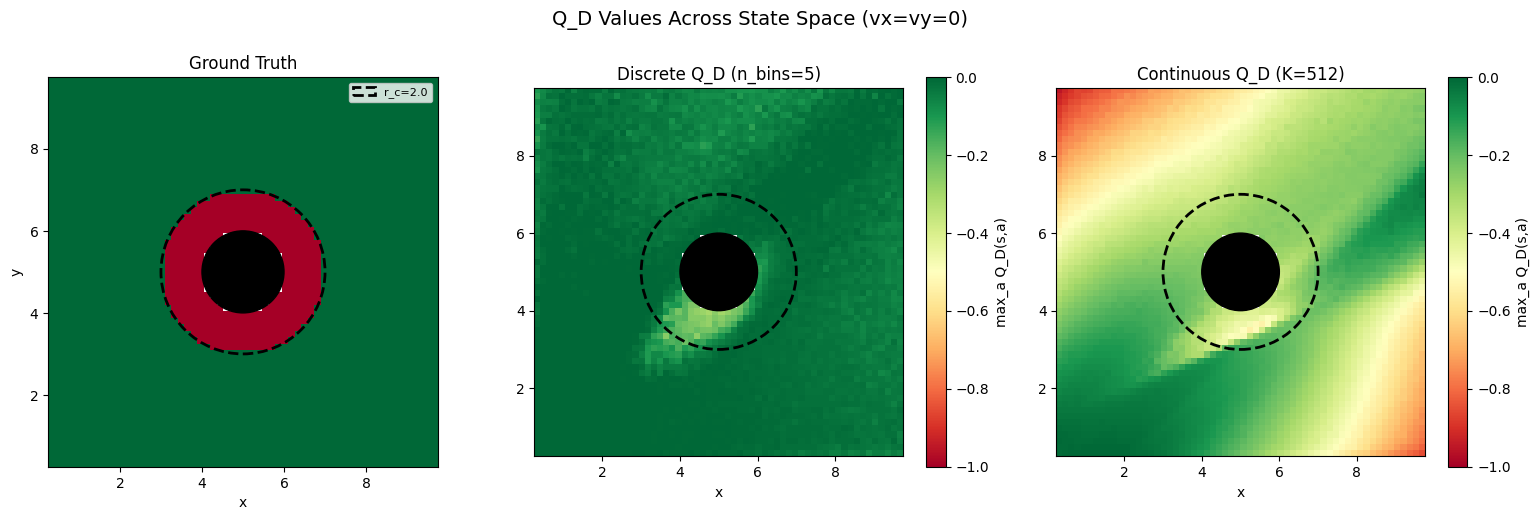

In [9]:
def scores_to_grid(scores, states, res=GRID_RES, margin=0.25):
    """Re-project 1D score array back onto the 2D grid for imshow."""
    xs = np.linspace(margin, MAP_SIZE - margin, res)
    ys = np.linspace(margin, MAP_SIZE - margin, res)
    xx, yy = np.meshgrid(xs, ys)
    dist_full = np.linalg.norm(
        np.stack([xx.ravel(), yy.ravel()], axis=1) - PLANET_CENTER, axis=1
    )
    inside_planet = dist_full < PLANET_RADIUS
    grid = np.full(res * res, np.nan)
    grid[~inside_planet] = scores
    return grid.reshape(res, res), xs, ys


def draw_boundary(ax, r_c=R_C, planet=PLANET_CENTER, **kw):
    circle = plt.Circle(planet, r_c, fill=False, **kw)
    ax.add_patch(circle)


def draw_planet(ax, planet=PLANET_CENTER, radius=PLANET_RADIUS):
    ax.add_patch(plt.Circle(planet, radius, color='black', zorder=5))


disc_grid, xs, ys = scores_to_grid(disc_Qd_scores, states)
cont_grid, _,  _  = scores_to_grid(cont_Qd_scores, states)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
extent = [xs[0], xs[-1], ys[0], ys[-1]]
vmin, vmax = -1, 0
cmap = 'RdYlGn'

# Ground truth
ax = axes[0]
gt_grid = np.full(GRID_RES * GRID_RES, np.nan)
dist_full = np.linalg.norm(
    np.stack([xx.ravel(), yy.ravel()], axis=1) - PLANET_CENTER, axis=1
)
mask_full = dist_full >= PLANET_RADIUS
gt_full = dist_full[mask_full] < R_C
gt_grid[mask_full] = gt_full.astype(float) * -1.0  # -1=dead end, 0=safe
im = ax.imshow(gt_grid.reshape(GRID_RES, GRID_RES), origin='lower',
               extent=extent, cmap='RdYlGn', vmin=-1, vmax=0, aspect='equal')
draw_boundary(ax, color='black', linewidth=2, linestyle='--', label=f'r_c={R_C}')
draw_planet(ax)
ax.set_title('Ground Truth', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=8)

# Discrete
ax = axes[1]
im1 = ax.imshow(disc_grid, origin='lower', extent=extent,
                cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
draw_boundary(ax, color='black', linewidth=2, linestyle='--')
draw_planet(ax)
ax.set_title(f'Discrete Q_D (n_bins={n_bins})', fontsize=12)
ax.set_xlabel('x')
plt.colorbar(im1, ax=ax, label='max_a Q_D(s,a)')

# Continuous
ax = axes[2]
im2 = ax.imshow(cont_grid, origin='lower', extent=extent,
                cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
draw_boundary(ax, color='black', linewidth=2, linestyle='--')
draw_planet(ax)
ax.set_title(f'Continuous Q_D (K={K_EVAL})', fontsize=12)
ax.set_xlabel('x')
plt.colorbar(im2, ax=ax, label='max_a Q_D(s,a)')

fig.suptitle('Q_D Values Across State Space (vx=vy=0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig1_qd_heatmaps.pdf', bbox_inches='tight')
plt.show()

## 7. Figure 2 — Predicted Dead-End Boundary

Shows where each agent draws the dead-end boundary at its optimal threshold, compared to the true circle at r_c.

NameError: name 'disc_Qd_scores' is not defined

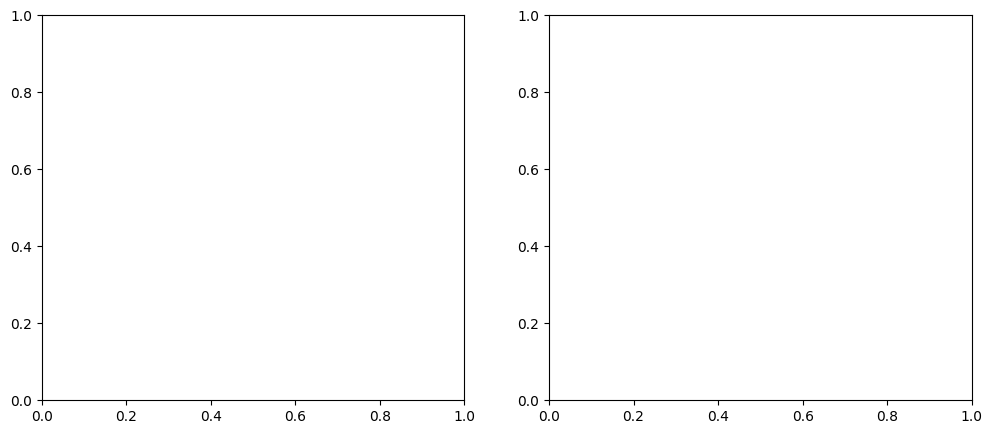

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, opt_t, label, color in [
    (axes[0], disc_Qd_scores, disc_opt_t, f'Discrete (n_bins={n_bins})', 'steelblue'),
    (axes[1], cont_Qd_scores, cont_opt_t, f'Continuous (K={K_EVAL})',    'darkorange'),
]:
    grid, xs, ys = scores_to_grid(scores, states)

    try:
        ax.contourf(xs, ys, grid, levels=[-1.0, opt_t, 0.0],
                    colors=['#f4a261', '#e9f5e9'], alpha=0.6)
    except Exception:   #For debugging purposes when the values in opt_t are not increasing
        safe_opt_t = np.clip(opt_t, -0.999, -0.001)
        ax.contourf(xs, ys, grid, levels=[-1.0, safe_opt_t, 0.0],
                    colors=['#f4a261', '#e9f5e9'], alpha=0.6)

    ax.contour(xs, ys, grid, levels=[opt_t],
               colors=[color], linewidths=2, label=f'Predicted boundary (t={opt_t:.2f})')
    draw_boundary(ax, color='black', linewidth=2.5, linestyle='--', label=f'True r_c={R_C}')
    draw_planet(ax)
    ax.set_xlim(0, MAP_SIZE); ax.set_ylim(0, MAP_SIZE)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.annotate('Dead-end region', xy=(5, 3.8), ha='center', fontsize=9, color='#c44e52')
    ax.annotate('Safe region', xy=(5, 7.5), ha='center', fontsize=9, color='#4c9a4c')

fig.suptitle('Predicted vs True Dead-End Boundary', fontsize=14)
plt.tight_layout()
plt.savefig('fig2_boundary.pdf', bbox_inches='tight')
plt.show()

## 8. Figure 3 — Error Maps (TP / FP / FN / TN)

Spatial map of classification errors. FP = safe state labelled as dead end (unnecessary restriction). FN = dead-end state missed (safety failure).

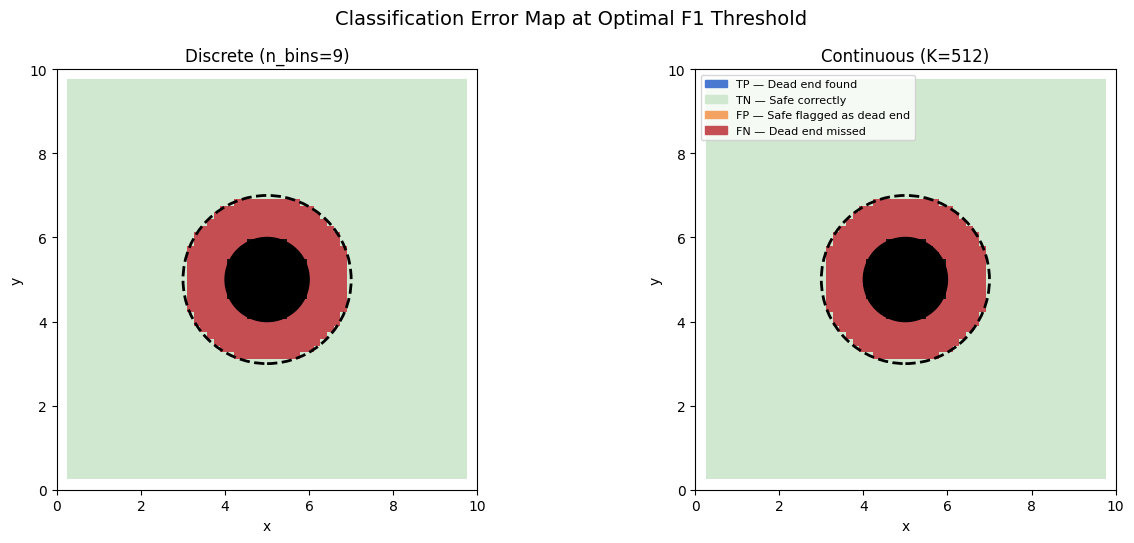

In [ ]:
def error_map(scores, gt, threshold, res=GRID_RES, margin=0.25):
    """Returns a (N,) integer array: 0=TN, 1=FP, 2=FN, 3=TP."""
    pred = scores < threshold
    code = np.where( pred &  gt, 3,   # TP — correctly identified dead end
           np.where( pred & ~gt, 1,   # FP — false alarm
           np.where(~pred &  gt, 2,   # FN — missed dead end
                                  0)))  # TN — correctly identified safe
    # Map back to full grid
    xs = np.linspace(margin, MAP_SIZE - margin, res)
    ys = np.linspace(margin, MAP_SIZE - margin, res)
    xx, yy = np.meshgrid(xs, ys)
    dist_full = np.linalg.norm(
        np.stack([xx.ravel(), yy.ravel()], axis=1) - PLANET_CENTER, axis=1
    )
    inside_planet = dist_full < PLANET_RADIUS
    grid = np.full(res * res, -1, dtype=int)
    grid[~inside_planet] = code
    return grid.reshape(res, res), xs, ys


error_colors = {-1: '#111111', 0: '#d0e8d0', 1: '#f4a261', 2: '#c44e52', 3: '#4878cf'}
cmap_err = mcolors.ListedColormap(['#111111', '#d0e8d0', '#f4a261', '#c44e52', '#4878cf'])
bounds_err = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5]
norm_err   = mcolors.BoundaryNorm(bounds_err, cmap_err.N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, scores, opt_t, label in [
    (axes[0], disc_Qd_scores, disc_opt_t, f'Discrete (n_bins={n_bins})'),
    (axes[1], cont_Qd_scores, cont_opt_t, f'Continuous (K={K_EVAL})'),
]:
    grid, xs, ys = error_map(scores, gt_labels, opt_t)
    extent = [xs[0], xs[-1], ys[0], ys[-1]]
    ax.imshow(grid, origin='lower', extent=extent,
              cmap=cmap_err, norm=norm_err, aspect='equal', interpolation='nearest')
    draw_boundary(ax, color='black', linewidth=2, linestyle='--')
    draw_planet(ax)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(0, MAP_SIZE); ax.set_ylim(0, MAP_SIZE)

legend_elements = [
    mpatches.Patch(color='#4878cf', label='TP — Dead end found'),
    mpatches.Patch(color='#d0e8d0', label='TN — Safe correctly'),
    mpatches.Patch(color='#f4a261', label='FP — Safe flagged as dead end'),
    mpatches.Patch(color='#c44e52', label='FN — Dead end missed'),
]
axes[1].legend(handles=legend_elements, loc='upper left', fontsize=8)

fig.suptitle('Classification Error Map at Optimal F1 Threshold', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_error_maps.pdf', bbox_inches='tight')
plt.show()

## 9. Figure 4 — ROC Curves

Receiver Operating Characteristic. A perfect classifier hugs the top-left. Area under curve (AUC-ROC) close to 1.0 is ideal.

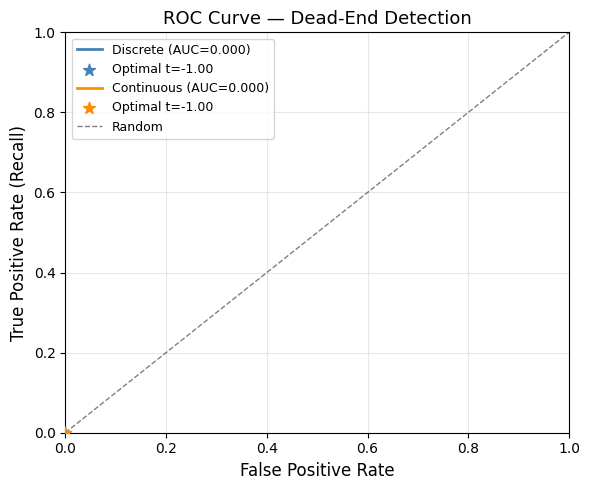

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

for curve, label, color, opt_t, scores in [
    (disc_curve, f'Discrete (AUC={disc_auc_roc:.3f})', 'steelblue',  disc_opt_t, disc_Qd_scores),
    (cont_curve, f'Continuous (AUC={cont_auc_roc:.3f})', 'darkorange', cont_opt_t, cont_Qd_scores),
]:
    order = np.argsort(curve['fpr'])
    ax.plot(curve['fpr'][order], curve['tpr'][order], color=color, lw=2, label=label)
    # Mark optimal threshold point
    m = classification_at_threshold(scores, gt_labels, opt_t)
    ax.scatter(m['fpr'], m['recall'], color=color, s=80, zorder=5,
               marker='*', label=f'Optimal t={opt_t:.2f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Dead-End Detection', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('fig4_roc.pdf', bbox_inches='tight')
plt.show()

## 10. Figure 5 — Precision-Recall Curves

PR curves are more informative than ROC when the class distribution is imbalanced. AUC-PR close to 1.0 is ideal. Random baseline = fraction of positive class.

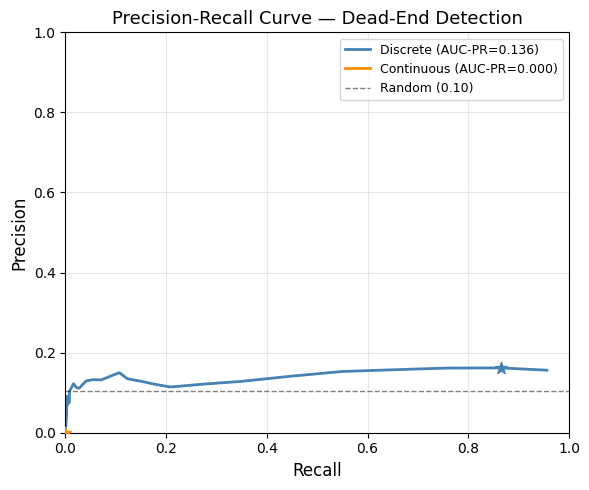

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

random_baseline = gt_labels.mean()

for curve, label, color, opt_t, scores in [
    (disc_curve, f'Discrete (AUC-PR={disc_auc_pr:.3f})', 'steelblue',  disc_opt_t, disc_Qd_scores),
    (cont_curve, f'Continuous (AUC-PR={cont_auc_pr:.3f})', 'darkorange', cont_opt_t, cont_Qd_scores),
]:
    order = np.argsort(curve['recall'])
    ax.plot(curve['recall'][order], curve['precision'][order],
            color=color, lw=2, label=label)
    m = classification_at_threshold(scores, gt_labels, opt_t)
    ax.scatter(m['recall'], m['precision'], color=color, s=80, zorder=5, marker='*')

ax.axhline(random_baseline, color='k', linestyle='--', lw=1,
           alpha=0.5, label=f'Random ({random_baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Dead-End Detection', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('fig5_pr_curve.pdf', bbox_inches='tight')
plt.show()

## 11. Figure 6 — Metrics by Distance Zone

The core plot for the thesis argument. Errors should concentrate in the boundary zone (|d − r_c| < δ) for the discrete agent, because that is where the angular escape window is narrow and grid points may miss it.

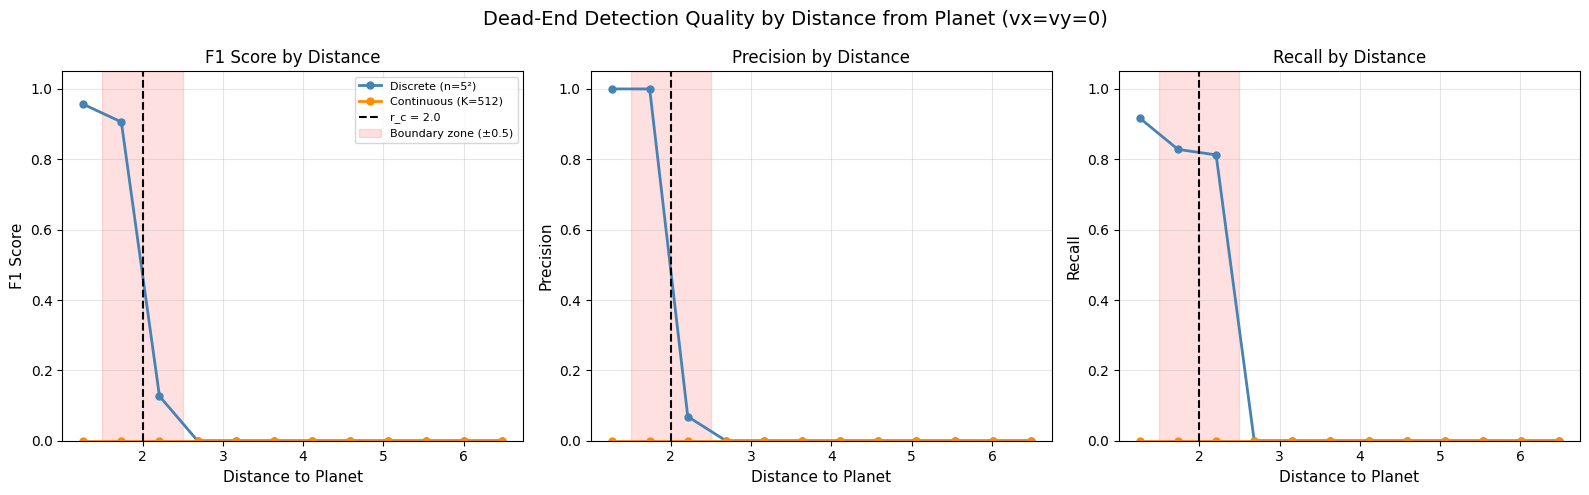

In [ ]:
def zone_metrics(scores, gt, threshold, dist, n_distance_bins=12):
    """Compute precision/recall/F1 in equal-width distance bins."""
    edges = np.linspace(dist.min(), dist.max(), n_distance_bins + 1)
    centres, precs, recs, f1s, sizes = [], [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (dist >= lo) & (dist < hi)
        if mask.sum() < 5:
            continue
        m = classification_at_threshold(scores[mask], gt[mask], threshold)
        centres.append((lo + hi) / 2)
        precs.append(m['precision'])
        recs.append(m['recall'])
        f1s.append(m['f1'])
        sizes.append(mask.sum())
    return np.array(centres), np.array(precs), np.array(recs), np.array(f1s), np.array(sizes)


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for col, (metric_key, metric_label) in enumerate([
    ('f1', 'F1 Score'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
]):
    ax = axes[col]
    for scores, opt_t, label, color in [
        (disc_Qd_scores, disc_opt_t, f'Discrete (n={n_bins}²)', 'steelblue'),
        (cont_Qd_scores, cont_opt_t, f'Continuous (K={K_EVAL})',  'darkorange'),
    ]:
        # Compute per-bin metrics (reuse sweep function per zone)
        centres, precs, recs, f1s, _ = zone_metrics(
            scores, gt_labels, opt_t, dist_to_planet
        )
        vals = {'f1': f1s, 'precision': precs, 'recall': recs}[metric_key]
        ax.plot(centres, vals, '-o', color=color, lw=2, ms=5, label=label)

    # Mark r_c and boundary zone
    ax.axvline(R_C, color='black', linestyle='--', lw=1.5, label=f'r_c = {R_C}')
    ax.axvspan(R_C - DELTA_BOUNDARY, R_C + DELTA_BOUNDARY,
               alpha=0.12, color='red', label=f'Boundary zone (±{DELTA_BOUNDARY})')
    ax.set_xlabel('Distance to Planet', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label} by Distance', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8)

fig.suptitle('Dead-End Detection Quality by Distance from Planet (vx=vy=0)', fontsize=14)
plt.tight_layout()
plt.savefig('fig6_metrics_by_zone.pdf', bbox_inches='tight')
plt.show()

## 12. Figure 7 — Q_D Score Distributions

Histograms of dead-end scores split by ground-truth label. A well-calibrated agent should show two separated peaks (dead ends near -1, safe states near 0). Overlap in the distributions indicates uncertain boundary detection.

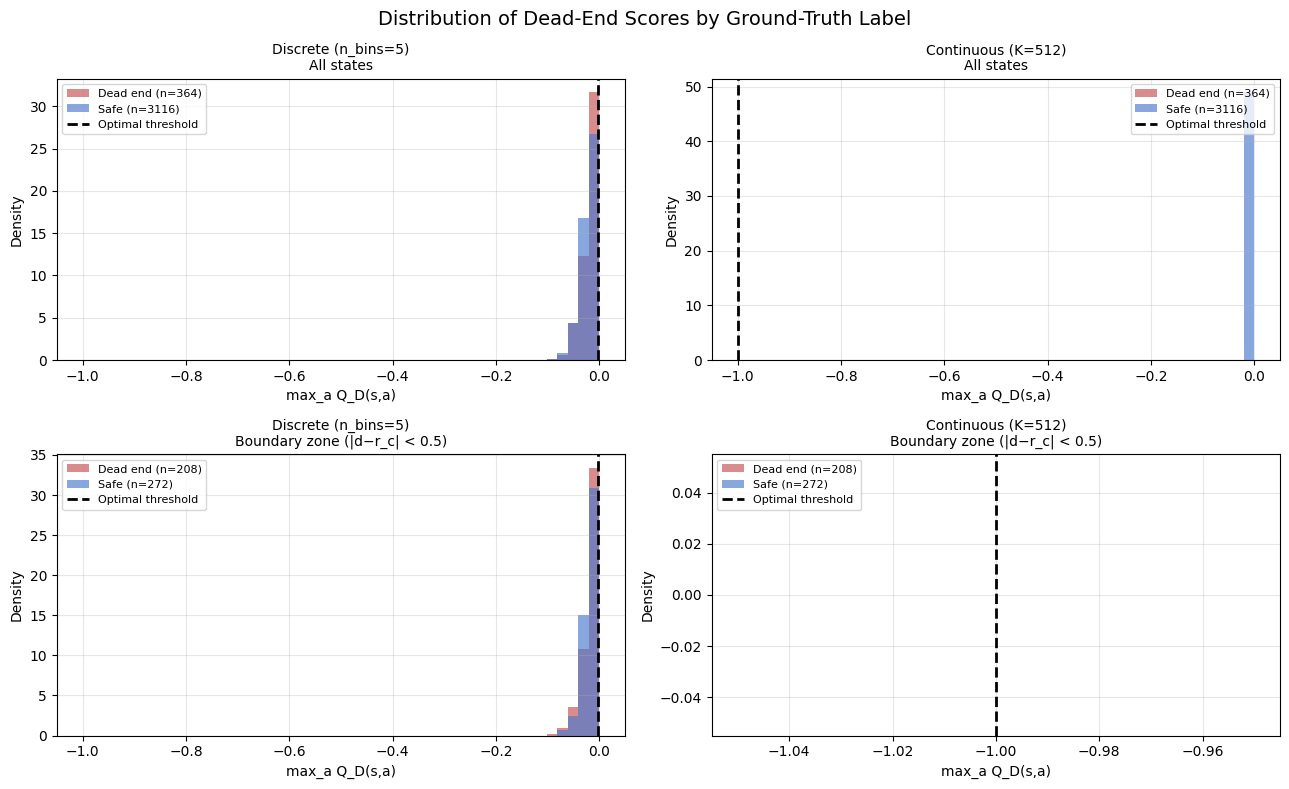

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
bins_hist = np.linspace(-1, 0, 50)

for row, (zone_mask, zone_name) in enumerate([
    (np.ones(len(gt_labels), dtype=bool), 'All states'),
    (zone_boundary, f'Boundary zone (|d−r_c| < {DELTA_BOUNDARY})'),
]):
    for col, (scores, label) in enumerate([
        (disc_Qd_scores, f'Discrete (n_bins={n_bins})'),
        (cont_Qd_scores, f'Continuous (K={K_EVAL})'),
    ]):
        ax = axes[row][col]
        s_de  = scores[zone_mask &  gt_labels]
        s_safe = scores[zone_mask & ~gt_labels]
        ax.hist(s_de,   bins=bins_hist, alpha=0.65, color='#c44e52',
                density=True, label=f'Dead end (n={len(s_de)})')
        ax.hist(s_safe, bins=bins_hist, alpha=0.65, color='#4878cf',
                density=True, label=f'Safe (n={len(s_safe)})')
        ax.axvline(disc_opt_t if col == 0 else cont_opt_t,
                   color='black', lw=2, linestyle='--', label='Optimal threshold')
        ax.set_xlabel('max_a Q_D(s,a)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{label}\n{zone_name}', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Distribution of Dead-End Scores by Ground-Truth Label', fontsize=14)
plt.tight_layout()
plt.savefig('fig7_score_distributions.pdf', bbox_inches='tight')
plt.show()

## 13. Figure 8 — Action Coverage Polar Plot

**The mechanistic explanation.** For states near r_c, the escape thrust must point approximately *away from the planet*. This plot shows:
- The discrete action grid on the unit circle (normalised thrust vectors)
- The required escape directions for boundary states
- The angular gap between each escape direction and the nearest grid action

Large gaps = the discrete agent cannot execute the optimal escape thrust.

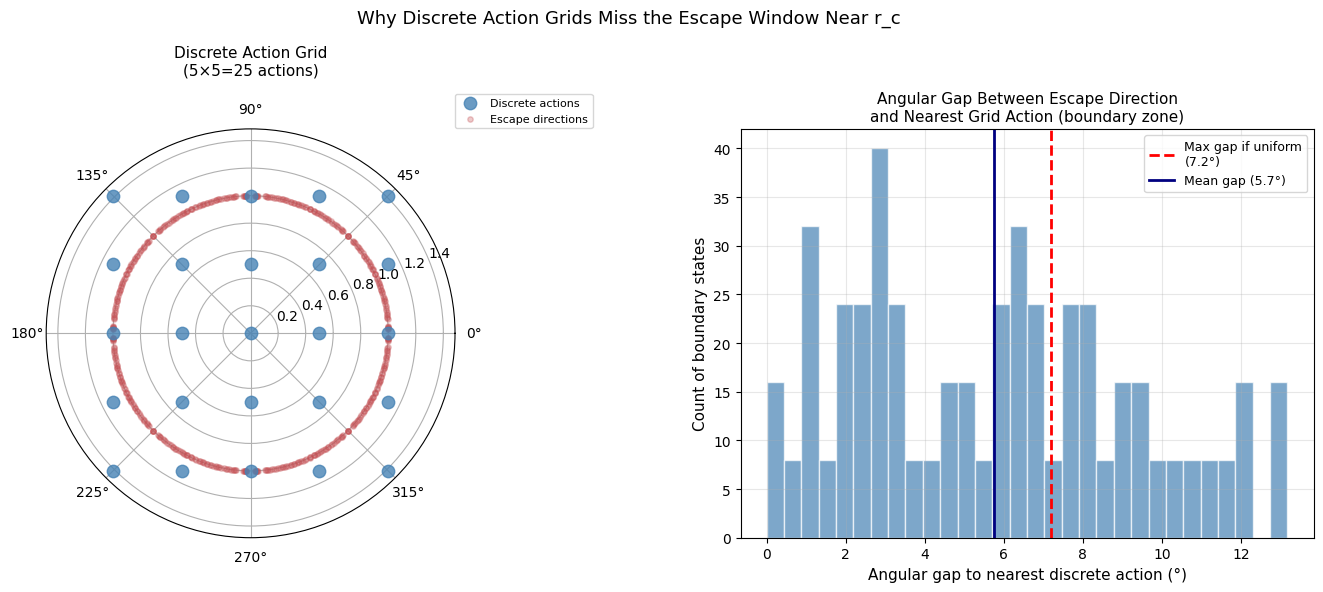

Mean angular gap to nearest grid action: 5.7°
Max  angular gap to nearest grid action: 13.2°
States with gap > 20°: 0 / 480


In [ ]:
fig = plt.figure(figsize=(14, 6))

# ── Left: discrete action grid on unit circle ─────────────────────────────
ax_polar = fig.add_subplot(121, projection='polar')

# Normalise each grid action to the unit circle
norms = np.linalg.norm(ACTION_MAP, axis=1)
norms[norms < 1e-6] = 1e-6  # avoid div-by-zero for (0,0) action
unit_actions = ACTION_MAP / norms[:, None]
angles_grid = np.arctan2(unit_actions[:, 1], unit_actions[:, 0])
magnitudes  = norms / A_MAX  # normalised to [0,1]

ax_polar.scatter(angles_grid, magnitudes, s=80, color='steelblue',
                 alpha=0.8, zorder=5, label='Discrete actions')

# Escape directions for boundary-zone states
boundary_states = states[zone_boundary]
escape_dirs = boundary_states[:, :2] - PLANET_CENTER  # point away from planet
escape_norms = np.linalg.norm(escape_dirs, axis=1, keepdims=True)
escape_dirs  = escape_dirs / (escape_norms + 1e-6)
escape_angles = np.arctan2(escape_dirs[:, 1], escape_dirs[:, 0])

ax_polar.scatter(escape_angles, np.ones(len(escape_angles)),
                 s=15, color='#c44e52', alpha=0.3, zorder=3, label='Escape directions')

ax_polar.set_title(f'Discrete Action Grid\n({n_bins}×{n_bins}={len(ACTION_MAP)} actions)',
                    fontsize=11, pad=20)
ax_polar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

# ── Right: angular gap histogram ──────────────────────────────────────────
ax_hist = fig.add_subplot(122)

def angular_gap(escape_angle, grid_angles):
    """Minimum absolute angular difference between escape dir and any grid action."""
    diffs = np.abs(escape_angle - grid_angles)
    diffs = np.minimum(diffs, 2 * np.pi - diffs)  # wrap around
    return np.degrees(diffs.min())

gaps = np.array([angular_gap(a, angles_grid) for a in escape_angles])

# Maximum gap for a uniform grid of n_actions actions on the circle
ideal_max_gap = 360.0 / len(ACTION_MAP) / 2

ax_hist.hist(gaps, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax_hist.axvline(ideal_max_gap, color='red', linestyle='--', lw=2,
                label=f'Max gap if uniform\n({ideal_max_gap:.1f}°)')
ax_hist.axvline(gaps.mean(), color='navy', linestyle='-', lw=2,
                label=f'Mean gap ({gaps.mean():.1f}°)')
ax_hist.set_xlabel('Angular gap to nearest discrete action (°)', fontsize=11)
ax_hist.set_ylabel('Count of boundary states', fontsize=11)
ax_hist.set_title(
    f'Angular Gap Between Escape Direction\nand Nearest Grid Action (boundary zone)',
    fontsize=11)
ax_hist.legend(fontsize=9)
ax_hist.grid(True, alpha=0.3)

fig.suptitle('Why Discrete Action Grids Miss the Escape Window Near r_c', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_action_coverage.pdf', bbox_inches='tight')
plt.show()

print(f'Mean angular gap to nearest grid action: {gaps.mean():.1f}°')
print(f'Max  angular gap to nearest grid action: {gaps.max():.1f}°')
print(f'States with gap > 20°: {(gaps > 20).sum()} / {len(gaps)}')

## 14. Figure 9 — Confusion Matrices

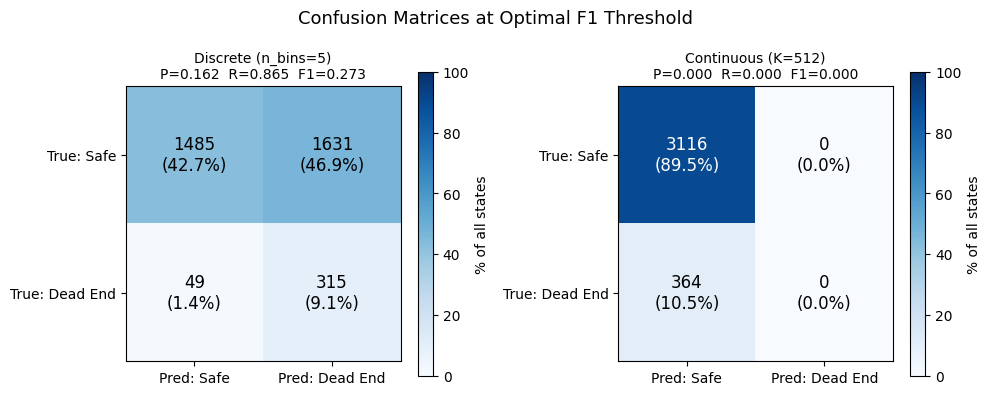

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, scores, opt_t, title in [
    (axes[0], disc_Qd_scores, disc_opt_t, f'Discrete (n_bins={n_bins})'),
    (axes[1], cont_Qd_scores, cont_opt_t, f'Continuous (K={K_EVAL})'),
]:
    m = classification_at_threshold(scores, gt_labels, opt_t)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    total = cm.sum()
    cm_pct = 100 * cm / total

    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=12,
                    color='white' if cm_pct[i, j] > 50 else 'black')

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Safe', 'Pred: Dead End'], fontsize=10)
    ax.set_yticklabels(['True: Safe', 'True: Dead End'], fontsize=10)
    ax.set_title(
        f'{title}\nP={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}',
        fontsize=10)
    plt.colorbar(im, ax=ax, label='% of all states')

fig.suptitle('Confusion Matrices at Optimal F1 Threshold', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_confusion.pdf', bbox_inches='tight')
plt.show()

## 15. Figure 10 — Q_R Rescue Network Analysis

Q_R captures states from which positive reward (survival/rescue) is possible. A good Q_R network assigns high values to states outside r_c and near-zero inside.

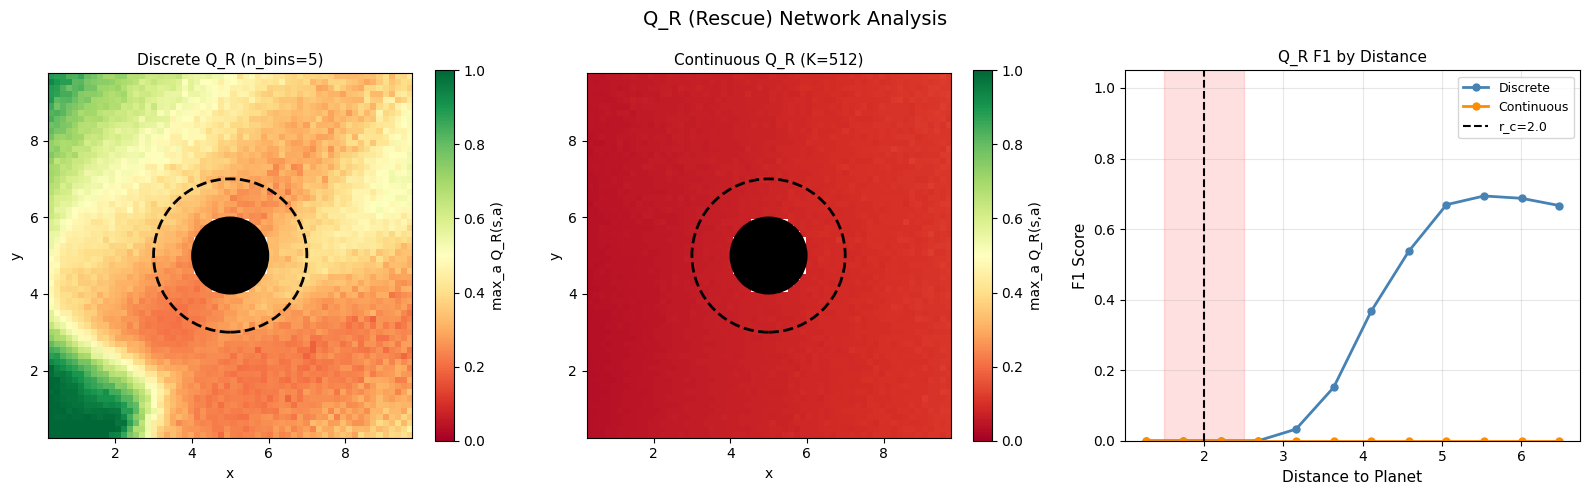

In [ ]:
# For rescue: label = NOT dead end (rescuable states are safe states)
rescue_labels = ~gt_labels  # True = rescuable

# Q_R > threshold → predict rescuable (reverse sign convention)
def classify_rescue(scores, threshold):
    """Classify as rescuable if max_a Q_R(s,a) >= threshold."""
    return scores >= threshold

def rescue_metrics_at_threshold(scores, gt_rescue, threshold):
    pred = classify_rescue(scores, threshold)
    gt   = gt_rescue
    TP = (pred &  gt).sum()
    FP = (pred & ~gt).sum()
    FN = (~pred &  gt).sum()
    TN = (~pred & ~gt).sum()
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return dict(precision=precision, recall=recall, f1=f1)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rescue_thresholds = np.linspace(0, 1, 200)

# Spatial heatmap
disc_Qr_grid, xs, ys = scores_to_grid(disc_Qr_scores, states)
cont_Qr_grid, _,  _  = scores_to_grid(cont_Qr_scores, states)
extent = [xs[0], xs[-1], ys[0], ys[-1]]

for ax, grid, label in [
    (axes[0], disc_Qr_grid, f'Discrete Q_R (n_bins={n_bins})'),
    (axes[1], cont_Qr_grid, f'Continuous Q_R (K={K_EVAL})'),
]:
    im = ax.imshow(grid, origin='lower', extent=extent,
                   cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
    draw_boundary(ax, color='black', linewidth=2, linestyle='--')
    draw_planet(ax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, label='max_a Q_R(s,a)')

# F1 by distance for Q_R
ax = axes[2]
for scores, opt_t_Qr, label, color in [
    (disc_Qr_scores, 0.5, f'Discrete', 'steelblue'),
    (cont_Qr_scores, 0.5, f'Continuous', 'darkorange'),
]:
    edges = np.linspace(dist_to_planet.min(), dist_to_planet.max(), 13)
    cs, f1s = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (dist_to_planet >= lo) & (dist_to_planet < hi)
        if mask.sum() < 5: continue
        m = rescue_metrics_at_threshold(scores[mask], rescue_labels[mask], opt_t_Qr)
        cs.append((lo + hi) / 2)
        f1s.append(m['f1'])
    ax.plot(cs, f1s, '-o', color=color, lw=2, ms=5, label=label)

ax.axvline(R_C, color='black', linestyle='--', lw=1.5, label=f'r_c={R_C}')
ax.axvspan(R_C - DELTA_BOUNDARY, R_C + DELTA_BOUNDARY, alpha=0.12, color='red')
ax.set_xlabel('Distance to Planet', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Q_R F1 by Distance', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.suptitle('Q_R (Rescue) Network Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('fig10_qr_analysis.pdf', bbox_inches='tight')
plt.show()

## 16. Figure 11 — Boundary Zone Deep Dive

Zoomed view of the annular boundary zone. Highlights the specific states where discrete grids fail to identify the correct label due to the angular gap in action coverage.

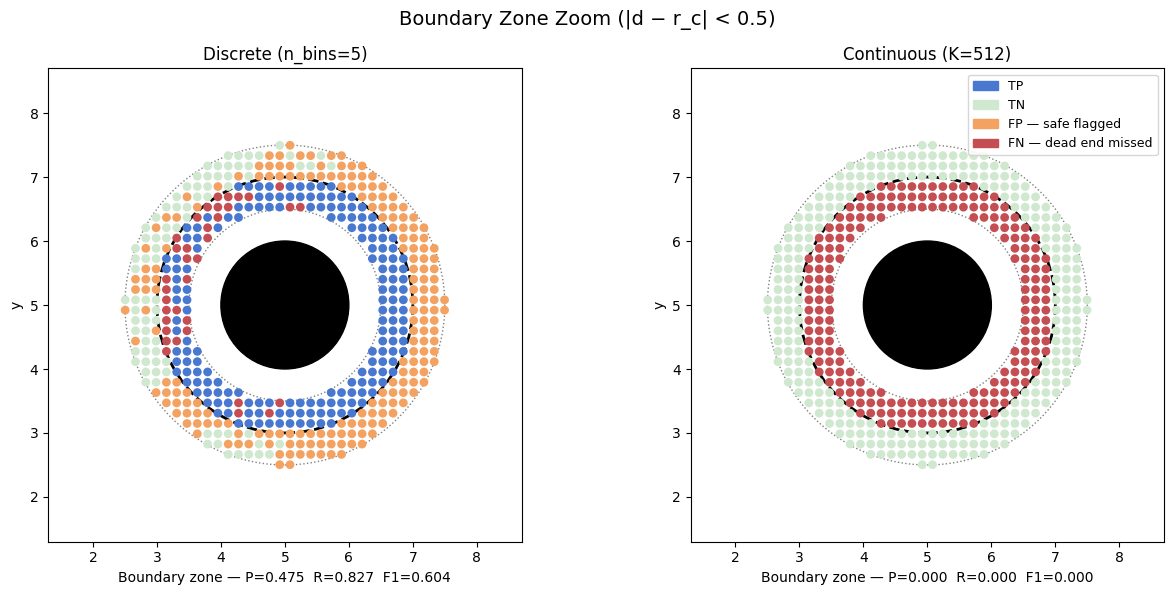

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, scores, opt_t, title in [
    (axes[0], disc_Qd_scores, disc_opt_t, f'Discrete (n_bins={n_bins})'),
    (axes[1], cont_Qd_scores, cont_opt_t, f'Continuous (K={K_EVAL})'),
]:
    pred = scores < opt_t
    # Colour by classification outcome for boundary zone
    bz_states = states[zone_boundary]
    bz_pred   = pred[zone_boundary]
    bz_gt     = gt_labels[zone_boundary]

    colors_map = {
        (True,  True):  '#4878cf',   # TP
        (False, False): '#d0e8d0',   # TN
        (True,  False): '#f4a261',   # FP
        (False, True):  '#c44e52',   # FN
    }
    point_colors = [colors_map[(bool(p), bool(g))] for p, g in zip(bz_pred, bz_gt)]

    ax.scatter(bz_states[:, 0], bz_states[:, 1],
               c=point_colors, s=40, zorder=4, edgecolors='none')

    draw_boundary(ax, color='black', linewidth=2, linestyle='--')
    ax.add_patch(plt.Circle(PLANET_CENTER, R_C - DELTA_BOUNDARY,
                            fill=False, color='gray', linestyle=':', lw=1))
    ax.add_patch(plt.Circle(PLANET_CENTER, R_C + DELTA_BOUNDARY,
                            fill=False, color='gray', linestyle=':', lw=1))
    draw_planet(ax)

    # Zoom to boundary zone
    zoom = DELTA_BOUNDARY + 1.2
    ax.set_xlim(PLANET_CENTER[0] - R_C - zoom, PLANET_CENTER[0] + R_C + zoom)
    ax.set_ylim(PLANET_CENTER[1] - R_C - zoom, PLANET_CENTER[1] + R_C + zoom)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    bz_m = classification_at_threshold(scores[zone_boundary], gt_labels[zone_boundary], opt_t)
    ax.set_xlabel(
        f'Boundary zone — P={bz_m["precision"]:.3f}  R={bz_m["recall"]:.3f}  F1={bz_m["f1"]:.3f}',
        fontsize=10
    )

legend_elements = [
    mpatches.Patch(color='#4878cf', label='TP'),
    mpatches.Patch(color='#d0e8d0', label='TN'),
    mpatches.Patch(color='#f4a261', label='FP — safe flagged'),
    mpatches.Patch(color='#c44e52', label='FN — dead end missed'),
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

fig.suptitle(f'Boundary Zone Zoom (|d − r_c| < {DELTA_BOUNDARY})', fontsize=14)
plt.tight_layout()
plt.savefig('fig11_boundary_zoom.pdf', bbox_inches='tight')
plt.show()

## 17. Summary Statistics Table

In [ ]:
def summarise(scores, gt, dist, opt_t, label):
    overall = classification_at_threshold(scores, gt, opt_t)
    bz_mask = (dist >= R_C - DELTA_BOUNDARY) & (dist <= R_C + DELTA_BOUNDARY)
    bz      = classification_at_threshold(scores[bz_mask], gt[bz_mask], opt_t)

    curve = sweep_thresholds(scores, gt)
    auc_roc = auc_trapz(curve['fpr'], curve['tpr'])
    auc_pr  = auc_trapz(curve['recall'], curve['precision'])

    return {
        'Agent':               label,
        'Optimal threshold':   f'{opt_t:.3f}',
        'Overall Precision':   f'{overall["precision"]:.3f}',
        'Overall Recall':      f'{overall["recall"]:.3f}',
        'Overall F1':          f'{overall["f1"]:.3f}',
        'Overall Accuracy':    f'{overall["accuracy"]:.3f}',
        'AUC-ROC':             f'{auc_roc:.3f}',
        'AUC-PR':              f'{auc_pr:.3f}',
        f'Boundary F1 (±{DELTA_BOUNDARY})':        f'{bz["f1"]:.3f}',
        f'Boundary Precision': f'{bz["precision"]:.3f}',
        f'Boundary Recall':    f'{bz["recall"]:.3f}',
        'Boundary FP':         str(bz['FP']),
        'Boundary FN':         str(bz['FN']),
    }


rows = [
    summarise(disc_Qd_scores, gt_labels, dist_to_planet, disc_opt_t,
              f'Discrete IQN (n_bins={n_bins})'),
    summarise(cont_Qd_scores, gt_labels, dist_to_planet, cont_opt_t,
              f'Continuous IQN (K={K_EVAL})'),
]

keys = list(rows[0].keys())
col_w = max(len(k) for k in keys) + 2
val_w = 30

print('\n' + '='*(col_w + val_w * len(rows) + 4))
print(f'{"Metric":<{col_w}}', end='')
for r in rows:
    print(f'{r["Agent"]:>{val_w}}', end='')
print()
print('-'*(col_w + val_w * len(rows) + 4))
for k in keys[1:]:  # skip Agent row
    print(f'{k:<{col_w}}', end='')
    for r in rows:
        print(f'{r[k]:>{val_w}}', end='')
    print()
print('='*(col_w + val_w * len(rows) + 4))


Metric                     Discrete IQN (n_bins=5)        Continuous IQN (K=512)
------------------------------------------------------------------------------------
Optimal threshold                           -0.003                        -1.000
Overall Precision                            0.162                         0.000
Overall Recall                               0.865                         0.000
Overall F1                                   0.273                         0.000
Overall Accuracy                             0.517                         0.895
AUC-ROC                                      0.274                         0.000
AUC-PR                                       0.136                         0.000
Boundary F1 (±0.5)                           0.604                         0.000
Boundary Precision                           0.475                         0.000
Boundary Recall                              0.827                         0.000
Boundary FP            

## 18. (Optional) Velocity Sensitivity

The fixed vx=vy=0 assumption above may be optimistic — a ship with inward velocity near r_c has even less ability to escape. This cell shows how metrics change as we add inward velocity to boundary states.

In [ ]:
inward_velocities = np.linspace(0, 0.5, 8)  # increasing inward velocity magnitude

disc_bz_f1_v, cont_bz_f1_v = [], []

for v_inward in inward_velocities:
    # Boundary-zone states with velocity pointing toward planet
    bz_states = states[zone_boundary].copy()
    directions = PLANET_CENTER - bz_states[:, :2]  # inward direction
    norms_dir  = np.linalg.norm(directions, axis=1, keepdims=True)
    bz_states[:, 2:4] = (directions / (norms_dir + 1e-6)) * v_inward  # set velocity

    bz_t = torch.FloatTensor(bz_states).to(device)
    bz_gt = gt_labels[zone_boundary]

    d_scores = score_discrete(disc_Qd, bz_t)
    c_scores = score_continuous(cont_Qd, bz_t, K=256)

    d_m = classification_at_threshold(d_scores, bz_gt, disc_opt_t)
    c_m = classification_at_threshold(c_scores, bz_gt, cont_opt_t)
    disc_bz_f1_v.append(d_m['f1'])
    cont_bz_f1_v.append(c_m['f1'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(inward_velocities, disc_bz_f1_v, '-o', color='steelblue', lw=2,
        label=f'Discrete (n_bins={n_bins})')
ax.plot(inward_velocities, cont_bz_f1_v, '-o', color='darkorange', lw=2,
        label=f'Continuous (K=256)')
ax.set_xlabel('Inward velocity magnitude (m/s)', fontsize=11)
ax.set_ylabel('F1 Score in boundary zone', fontsize=11)
ax.set_title('Dead-End Detection Quality vs Inward Velocity\n(boundary zone states)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_velocity_sensitivity.pdf', bbox_inches='tight')
plt.show()

NameError: name 'np' is not defined